Count number of entries in a .json file

In [ ]:
import json

# Replace this with the path to your .json file
json_path = "/store/real/hjchoi92/data/real/umift_data/WBW300-b1/processed_data/gopro_iphone/2025-03-27/2025-03-27T23-01-27.571Z_42591_WBW300-b1_demonstration/processed_left.json"

with open(json_path, 'r') as f:
    data = json.load(f)

print("Entry counts per key:")
for key, value in data.items():
    try:
        print(f"{key}: {len(value)}")
    except TypeError:
        print(f"{key}: Not a list (type = {type(value)})")


# Inspect raw RGB data


In [ ]:
import cv2
import matplotlib.pyplot as plt

video_path = '/store/real/hjchoi92/data/real/umift/WBW-iph-b0/processed_data/iphone/2025-04-17/2025-04-17T23-49-42.408Z_15397_WBW-iph-b0_demonstration/left_ultrawidergb.mp4'
image_output_res = (224, 224)  # Desired output resolution

# Open video file
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video: {video_path}")

# Get original width, height, and frame count
raw_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
raw_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

resize_factor = 1.2
downsample_factor = (image_output_res[0] * resize_factor) / min(raw_width, raw_height)
# original image size for {side}_ultrawidergb.mp4 : 640 x 480
temp_width = int(raw_width * downsample_factor)
temp_height = int(raw_height * downsample_factor)

print(f"Original video resolution: {raw_width} x {raw_height}")
print(f"Downscaled resolution: {int(raw_width * downsample_factor)} x {int(raw_height * downsample_factor)}")
print(f"Total number of frames: {frame_count}")

# Read a few sample frames (e.g., first 3)
sample_indices = [0, frame_count // 3, (2 * frame_count) // 3]
frames_original = []
frames_downscaled = []

for i in range(max(sample_indices) + 1):
    ret = cap.grab()
    if not ret:
        break
    if i in sample_indices:
        ret, frame = cap.retrieve()
        if not ret:
            continue
        frames_original.append(frame)
        frame_down = cv2.resize(frame, (int(raw_width * downsample_factor), int(raw_height * downsample_factor)))
        frames_downscaled.append(frame_down)

cap.release()

# Display side-by-side comparisons
for idx, (orig, down) in enumerate(zip(frames_original, frames_downscaled)):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Original Frame {sample_indices[idx]}')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(down, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Downscaled Frame {sample_indices[idx]}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


## Inspect Depth Data


In [ ]:
import sys
import os

# Append umi_day submodule to PYTHONPATH
sys.path.append(os.path.join(os.getcwd(), '..', 'submodules', 'umi_day'))

# Append PyriteUtility to PYTHONPATH (one level up from current directory)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'PyriteUtility')))

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path
from umi_day.common.cv_util import get_image_transform_with_border
from umi_day.demonstration_processing.utils.depth_util import load_depth

depth_file_path = Path("/store/real/hjchoi92/data/real/test/WBW-iph-b0/processed_data/iphone/2025-04-17/2025-04-17T23-24-27.773Z_93933_WBW-iph-b0_demonstration/left_depth.raw")  # adjust this
depth_array = load_depth(depth_file_path)
print("Raw depth shape:", depth_array.shape)  # (T, H, W)
print("depth length:", len(depth_array))

depth_length = len(depth_array)
depth_to_30hz_index = np.arange(depth_length // 2).repeat(2)
if len(depth_to_30hz_index) < depth_length:
    depth_to_30hz_index = np.append(depth_to_30hz_index, depth_to_30hz_index[-1])
print(depth_to_30hz_index)

def get_depth_transform_with_border(in_res, out_res):
    """
    Transform depth image to bordered square and resize while keeping float16
    Assumes input image shape: (H, W)
    """
    ih, iw = in_res  # width, height
    oh, ow = out_res  # should both be 224

    def transform(depth_img: np.ndarray):
        assert depth_img.shape == (ih, iw)
        assert depth_img.dtype == np.float16

        # Compute padding
        size = max(iw, ih)
        top = (size - ih) // 2
        bottom = size - ih - top
        left = (size - iw) // 2
        right = size - iw - left

        # Pad with 0 (assumes 0 = invalid depth)
        depth_padded = np.pad(depth_img, ((top, bottom), (left, right)), mode='constant', constant_values=0)

        # Resize using float32 interpolation (cv2 doesn't support float16 directly)
        depth_padded = depth_padded.astype(np.float32)
        resized = cv2.resize(depth_padded, dsize=out_res, interpolation=cv2.INTER_LINEAR)

        return resized.astype(np.float16)

    return transform



In [ ]:
plt.hist(depth_array[0].flatten(), bins=100)
plt.title("Histogram of first frame depth values")
plt.show()

In [ ]:
# depth_frame = depth_array[0]
# normalized = (depth_frame / np.nanmax(depth_frame) * 255).astype(np.uint8)
# rgb_like = np.stack([normalized]*3, axis=-1)  # (H, W, 3)

# plt.imshow(rgb_like)
# plt.title("Depth frame as 3-channel image")
# plt.show()

In [ ]:
# H, W = depth_frame.shape
# transform = get_image_transform_with_border(in_res=(W, H), out_res=(224, 224))
# resized_frame = transform(rgb_like)

# plt.imshow(resized_frame)
# plt.title("Resized depth frame to 224x224")
# plt.show()


In [ ]:
depth_frame = depth_array[0]
H, W = depth_frame.shape
transform = get_depth_transform_with_border(in_res=(W, H), out_res=(224, 224))
resized_frame = transform(depth_frame)

plt.imshow(resized_frame)
plt.title("Resized depth frame to 224x224")
plt.show()

In [ ]:
plt.hist(resized_frame.flatten(), bins=200)
plt.title("Histogram of depth values")
plt.show()

## Inspect Zarr File

eraser point: 0.5
eraser point: 0.1976
eraser point: 0.1582
eraser point: 0.1749
eraser point: 0.1698
eraser point: 0.1714


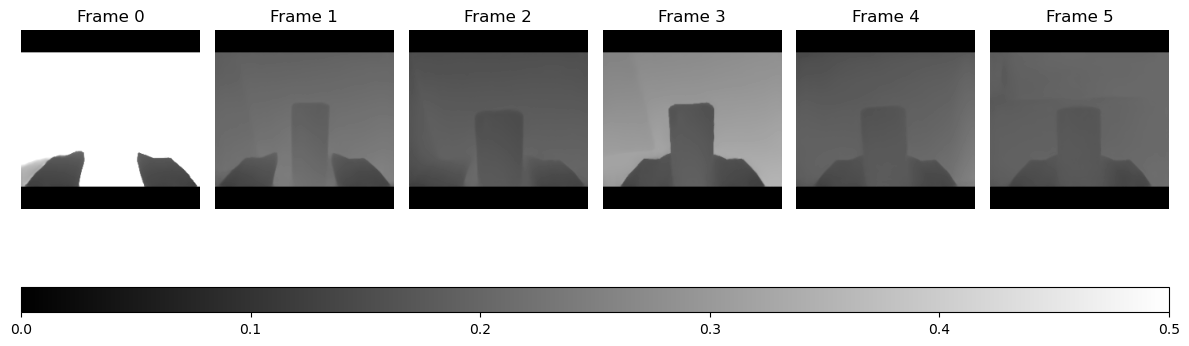

Original min/max: 0.0 0.5
Original: 0.5


In [47]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import matplotlib.gridspec as gridspec

zarr_path = '/store/real/hjchoi92/data/real/test/WBW-iph-b0/processed_data/all/acp_replay_buffer_gripper.zarr' 
zarr_data = zarr.open(zarr_path, mode='r')

ep_key = 'episode_2'
ep = zarr_data['data'][ep_key]

depth_raw = np.array(ep['depth_0'])
N = 6  # number of frames to show
vmin, vmax = 0.0, 0.5

# Plot a few clipped depth images (as grayscale)
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(2, N, height_ratios=[20, 1])  # 2 rows, last row for colorbar

C = 2
m = 100
axs = []
for i in range(N):
    ax = plt.subplot(gs[0, i])
    im = ax.imshow(depth_raw[i+i*m, :, :, C], cmap='gray', vmin=vmin, vmax=vmax)
    print("eraser point:", depth_raw[i+i*m, 130, 112, C])
    ax.set_title(f'Frame {i}')
    ax.axis('off')
    axs.append(ax)

# Add a colorbar below all plots
cax = plt.subplot(gs[1, :])
fig.colorbar(im, cax=cax, orientation='horizontal')

plt.tight_layout()
plt.show()
print("Original min/max:", np.min(depth_raw), np.max(depth_raw))

t, x, y = 10, 112, 112
print("Original:", depth_raw[t, x, y, 0])

In [52]:
rgb_ts = np.array(ep['rgb_time_stamps_0']).squeeze()
uw_ts = np.array(ep['ultrawide_time_stamps_0']).squeeze()
depth_ts = np.array(ep['depth_time_stamps_0']).squeeze()
map_to_depth = np.array(ep['map_to_d_idx_0']).squeeze()
map_to_uw_rgb = np.array(ep['map_to_uw_idx_0']).squeeze()

print("RGB timestamps length:", len(rgb_ts))
print("Depth timestamps length:", len(depth_ts))
print("Map to depth length:", len(map_to_depth))
print("map_to_d max:", np.max(map_to_depth))
print('map_to_uw_rgb:', len(map_to_uw_rgb))

print("map_to_depth:", map_to_depth)

# Compare RGB timestamp and mapped depth timestamp
mul = 30
for i in range(30):
    jmp = i * mul
    uw_idx = map_to_uw_rgb[i + jmp]
    d_idx = map_to_depth[i + jmp]
    print(f"RGB[{i + jmp}]: {rgb_ts[i + jmp]:.6f}  →  UW[{uw_idx}]: {uw_ts[uw_idx]:.6f}")
    print(f"RGB[{i + jmp}]: {rgb_ts[i + jmp]:.6f}  →  Depth[{d_idx}]: {depth_ts[d_idx]:.6f}")

RGB timestamps length: 1300
Depth timestamps length: 650
Map to depth length: 1300
map_to_d max: 649
map_to_uw_rgb: 1300
map_to_depth: [  0   0   1 ... 648 649 649]
RGB[0]: 4.776204  →  UW[0]: 4.809204
RGB[0]: 4.776204  →  Depth[0]: 4.776204
RGB[31]: 5.293204  →  UW[4]: 5.209204
RGB[31]: 5.293204  →  Depth[15]: 5.276204
RGB[62]: 5.809204  →  UW[10]: 5.809204
RGB[62]: 5.809204  →  Depth[31]: 5.809204
RGB[93]: 6.326204  →  UW[15]: 6.310204
RGB[93]: 6.326204  →  Depth[46]: 6.310204
RGB[124]: 6.843204  →  UW[20]: 6.810204
RGB[124]: 6.843204  →  Depth[62]: 6.843204
RGB[155]: 7.360204  →  UW[25]: 7.310204
RGB[155]: 7.360204  →  Depth[77]: 7.343204
RGB[186]: 7.876204  →  UW[30]: 7.810204
RGB[186]: 7.876204  →  Depth[93]: 7.876204
RGB[217]: 8.393204  →  UW[35]: 8.310204
RGB[217]: 8.393204  →  Depth[108]: 8.376204
RGB[248]: 8.910204  →  UW[41]: 8.910204
RGB[248]: 8.910204  →  Depth[124]: 8.910204
RGB[279]: 9.426204  →  UW[46]: 9.410204
RGB[279]: 9.426204  →  Depth[139]: 9.410204
RGB[310]: 9.943